In [10]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

In [11]:
(xtrain,ytrain),(xtest,ytest)=keras.datasets.cifar10.load_data()

In [12]:
xtrain.shape

(50000, 32, 32, 3)

In [13]:
ytrain.shape

(50000, 1)

In [14]:
xtrain

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

RESHAPE Y TRAIN

In [23]:
ytrain=ytrain.reshape(-1,)

In [24]:
classes = ["aeroplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

## FOR LABELING,SIZE 

Text(0.5, 0, 'frog')

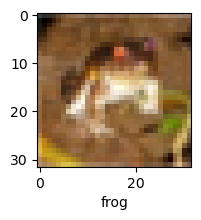

In [29]:
plt.figure(figsize=(15,2))
plt.imshow(xtrain[0])
plt.xlabel(classes[ytrain[0]])

FUN TO GET PLOT FIGURES

In [30]:
def pltfig(x,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

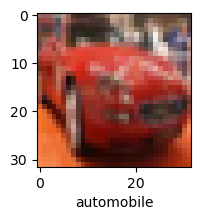

In [32]:
pltfig(xtrain,ytrain,5)

SCALING

In [35]:
xtrain=xtrain/255
xtest=xtest/255
xtrain

array([[[[3.55820914e-06, 3.73913502e-06, 3.79944365e-06],
         [2.59327106e-06, 2.77419695e-06, 2.71388832e-06],
         [3.01543147e-06, 2.89481421e-06, 2.59327106e-06],
         ...,
         [9.52876345e-06, 7.96073908e-06, 6.51333198e-06],
         [9.16691167e-06, 7.53857868e-06, 6.15148020e-06],
         [8.92567715e-06, 7.47827005e-06, 6.21178883e-06]],

        [[9.64938071e-07, 1.20617259e-06, 1.20617259e-06],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.08555533e-06, 4.82469035e-07, 0.00000000e+00],
         ...,
         [7.41796142e-06, 5.30715939e-06, 3.31697462e-06],
         [7.17672690e-06, 5.00561624e-06, 3.01543147e-06],
         [7.35765279e-06, 5.24685076e-06, 3.43759188e-06]],

        [[1.50771574e-06, 1.44740711e-06, 1.26648122e-06],
         [9.64938071e-07, 4.22160406e-07, 0.00000000e+00],
         [2.95512284e-06, 1.62833299e-06, 4.82469035e-07],
         ...,
         [7.11641827e-06, 5.06592487e-06, 3.01543147e-06],
         [

In [36]:
xtest

array([[[[0.61960784, 0.43921569, 0.19215686],
         [0.62352941, 0.43529412, 0.18431373],
         [0.64705882, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254902, 0.14117647],
         [0.49411765, 0.35686275, 0.14117647],
         [0.45490196, 0.33333333, 0.12941176]],

        [[0.59607843, 0.43921569, 0.2       ],
         [0.59215686, 0.43137255, 0.15686275],
         [0.62352941, 0.44705882, 0.17647059],
         ...,
         [0.53333333, 0.37254902, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509804, 0.13333333]],

        [[0.59215686, 0.43137255, 0.18431373],
         [0.59215686, 0.42745098, 0.12941176],
         [0.61960784, 0.43529412, 0.14117647],
         ...,
         [0.54509804, 0.38431373, 0.13333333],
         [0.50980392, 0.37254902, 0.13333333],
         [0.47058824, 0.34901961, 0.12941176]],

        ...,

        [[0.26666667, 0.48627451, 0.69411765],
         [0.16470588, 0.39215686, 0.58039216]

In [40]:
model=keras.Sequential(
    [keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='softmax')]
)


In [45]:
model.compile(
    optimizer='SGD', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [46]:
model.fit(xtrain,ytrain,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.0959 - loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.0975 - loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.0988 - loss: 2.3027
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.0968 - loss: 2.3027
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.0969 - loss: 2.3027


In [50]:
model.evaluate(xtest,ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0564 - loss: 2.4205


[2.420450448989868, 0.05640000104904175]

In [51]:
ypredict=model.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [53]:
y_predict=[np.argmax(i) for i in ypredict]

In [57]:
from sklearn.metrics import classification_report

In [60]:
print(classification_report(ytest,y_predict))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.05      0.17      0.08      1000
           3       0.00      0.00      0.00      1000
           4       0.06      0.01      0.01      1000
           5       0.00      0.00      0.00      1000
           6       0.14      0.06      0.09      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.05      0.32      0.09      1000

    accuracy                           0.06     10000
   macro avg       0.03      0.06      0.03     10000
weighted avg       0.03      0.06      0.03     10000



C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
cnnmodel=keras.Sequential(
    [keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
     keras.layers.MaxPooling2D((2,2)),
     keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
     keras.layers.MaxPooling2D((2,2)),

     keras.layers.Flatten(),
     keras.layers.Dense(64,activation='relu'),
     keras.layers.Dense(10,activation='softmax')]
)                         

C:\Users\HP\anaconda3\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
cnnmodel.compile(
    optimizer='SGD', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [71]:
cnnmodel.fit(xtrain,ytrain,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.0980 - loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.0993 - loss: 2.3027
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.0978 - loss: 2.3027
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.0977 - loss: 2.3027
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.0975 - loss: 2.3027


In [70]:
cnnmodel.evaluate(xtest,ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1018 - loss: 2.3066


[2.3066465854644775, 0.10180000215768814]

In [76]:
ypredict=cnnmodel.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [77]:
y_predict=[np.argmax(i) for i in ypredict]

In [78]:
from sklearn.metrics import classification_report

In [79]:
print(classification_report(ytest,y_predict))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.08      0.05      0.06      1000
           2       0.00      0.00      0.00      1000
           3       0.05      0.00      0.00      1000
           4       0.17      0.01      0.01      1000
           5       0.12      0.05      0.07      1000
           6       0.06      0.00      0.01      1000
           7       0.00      0.00      0.00      1000
           8       0.10      0.89      0.18      1000
           9       0.11      0.01      0.02      1000

    accuracy                           0.10     10000
   macro avg       0.07      0.10      0.04     10000
weighted avg       0.07      0.10      0.04     10000



C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\New folder\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
